In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv('./dataset/dataset1.csv')
df.columns = df.columns.str.strip()
df = df.drop('index', axis=1)
y = df['Result']
X = df.drop('Result', axis=1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [7]:
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.1]}, cv=3, n_jobs=-1)
gb_grid.fit(X_train_s, y_train)
bp = gb_grid.best_params_
print(bp)
pred = gb_grid.predict(X_test_s)
print(accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred, labels=[-1, 1]))
print(classification_report(y_test, pred, digits=4))

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
0.9724106739032112
[[ 941   39]
 [  22 1209]]
              precision    recall  f1-score   support

          -1     0.9772    0.9602    0.9686       980
           1     0.9688    0.9821    0.9754      1231

    accuracy                         0.9724      2211
   macro avg     0.9730    0.9712    0.9720      2211
weighted avg     0.9725    0.9724    0.9724      2211



In [8]:
#gradient boosting with feature engineering
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_fe = poly.fit_transform(X_train_s)
X_test_fe = poly.transform(X_test_s)
gb_fe = GradientBoostingClassifier(random_state=42, **bp).fit(X_train_fe, y_train)
pred_fe = gb_fe.predict(X_test_fe)
print(accuracy_score(y_test, pred_fe))
print(confusion_matrix(y_test, pred_fe, labels=[-1, 1]))
print(classification_report(y_test, pred_fe, digits=4))

0.9773857982813207
[[ 945   35]
 [  15 1216]]
              precision    recall  f1-score   support

          -1     0.9844    0.9643    0.9742       980
           1     0.9720    0.9878    0.9799      1231

    accuracy                         0.9774      2211
   macro avg     0.9782    0.9761    0.9770      2211
weighted avg     0.9775    0.9774    0.9774      2211



In [18]:
#gradient boosting with principle component analysis
pca = PCA(n_components=30, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)
gb_pca = GradientBoostingClassifier(random_state=42, **bp).fit(X_train_pca, y_train)
pred_pca = gb_pca.predict(X_test_pca)
print(accuracy_score(y_test, pred_pca))
print(confusion_matrix(y_test, pred_pca, labels=[-1, 1]))
print(classification_report(y_test, pred_pca, digits=4))

0.9687924016282226
[[ 932   48]
 [  21 1210]]
              precision    recall  f1-score   support

          -1     0.9780    0.9510    0.9643       980
           1     0.9618    0.9829    0.9723      1231

    accuracy                         0.9688      2211
   macro avg     0.9699    0.9670    0.9683      2211
weighted avg     0.9690    0.9688    0.9687      2211



## Interpret Gradient Boosting with Feature Engineering


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Get the names of the original and engineered interaction features
feature_names_fe = poly.get_feature_names_out(X.columns)

# Get feature importance values from the Gradient Boosting model
gb_fe_feature_importance = pd.DataFrame({
    "Feature": feature_names_fe,
    "Importance": gb_fe.feature_importances_
})

# Sort from most important to least important
gb_fe_feature_importance = gb_fe_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Most Important Features for Gradient Boosting with Interaction Features")
print("-------------------------------------------------------------------------------")
print(gb_fe_feature_importance.head(15))

Top 15 Most Important Features for Gradient Boosting with Interaction Features
-------------------------------------------------------------------------------
                                  Feature  Importance
7                          SSLfinal_State    0.647910
217          SSLfinal_State URL_of_Anchor    0.068154
13                          URL_of_Anchor    0.044086
218          SSLfinal_State Links_in_tags    0.014838
340             URL_of_Anchor web_traffic    0.011099
324               Request_URL web_traffic    0.010095
207         having_Sub_Domain web_traffic    0.009814
174                     Prefix_Suffix SFH    0.009042
187  Prefix_Suffix Links_pointing_to_page    0.008776
309              HTTPS_token Google_Index    0.006404
205       having_Sub_Domain age_of_domain    0.006030
166          Prefix_Suffix SSLfinal_State    0.005460
349            Links_in_tags on_mouseover    0.004590
71            URLURL_Length Links_in_tags    0.004256
329           URL_of_Anchor Lin

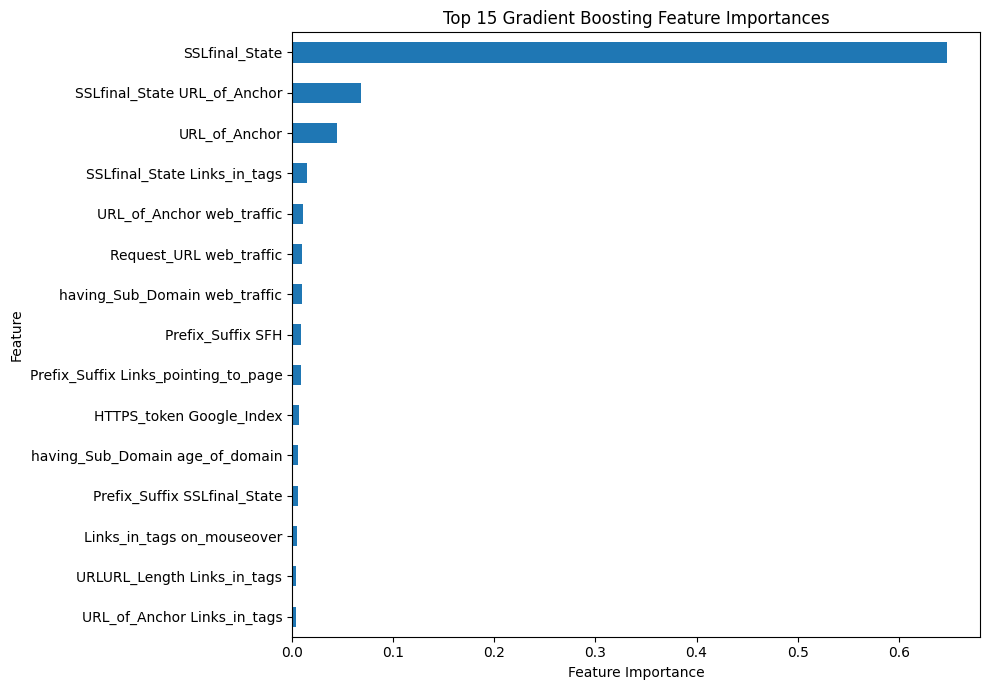

In [10]:
top_15_gb_fe = gb_fe_feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

top_15_gb_fe.plot.barh(
    x="Feature",
    y="Importance",
    title="Top 15 Gradient Boosting Feature Importances",
    legend=False,
    figsize=(10, 7)
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [11]:
top_5_importance = gb_fe_feature_importance.head(5)["Importance"].sum()
top_10_importance = gb_fe_feature_importance.head(10)["Importance"].sum()
top_15_importance = gb_fe_feature_importance.head(15)["Importance"].sum()

print("Total importance of top 5 features:", top_5_importance)
print("Total importance of top 10 features:", top_10_importance)
print("Total importance of top 15 features:", top_15_importance)

Total importance of top 5 features: 0.7860878482621605
Total importance of top 10 features: 0.830219320584591
Total importance of top 15 features: 0.8546928595689945
